In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
pd.set_option('display.min_rows', None)
pd.set_option('display.max_rows', None)

In [6]:
# manually replaced the TiS2 value with 2.37 W/mK
# from https://doi.org/10.1007/s43207-024-00368-y

In [7]:
#pulling the integer coefficient data
integersonly=pd.read_excel('thermodata.xlsx',sheet_name=0)

In [8]:
#pulling all the data
all=pd.read_excel('thermodata.xlsx',sheet_name=1)

In [9]:
integer=[] #selecting ones that have integer coefficients
for i in range(len(all)):
    if "." in all.iloc[i][0]:
        integer.append(1)
    else:
        integer.append(0)

/var/folders/vj/ybz4zyl541v64jxvktjgnb3m0000gp/T/ipykernel_18841/3818555443.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if "." in all.iloc[i][0]:


In [41]:
all['int']=integer

In [42]:
intsonly=all[all.int==0]

In [43]:
intsonly=intsonly.drop(['int'],axis=1)

In [44]:
intsonly.sort_values(by=['thermal_conductivity(W/mK)','Formula','temperature(K)'],inplace=True)
integeronly=intsonly.reset_index(drop=True)

In [45]:
integersonly.sort_values(by=['thermal_conductivity(W/mK)','Formula','temperature(K)'],inplace=True)
integersonly=integersonly.reset_index(drop=True)

In [50]:
#selecting a certain temperature range
coldintonly=integersonly.query('`temperature(K)` > 273')
goldintonly=coldintonly.query('`temperature(K)` < 500')

In [52]:
temptest=goldintonly.sort_values(by=['Formula','temperature(K)','thermal_conductivity(W/mK)'])

In [53]:
unique=temptest.drop_duplicates(subset=['Formula']) #taking the lowest temperature within the range

Text(0, 0.5, 'thermal_conductivity(W/mK)')

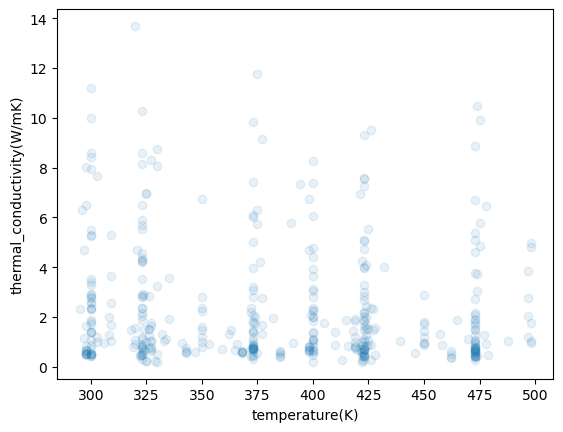

In [54]:
#temperatures before
plt.scatter(temptest.loc[:,'temperature(K)'],temptest.loc[:,'thermal_conductivity(W/mK)'],alpha=0.1)
plt.xlabel("temperature(K)")
plt.ylabel("thermal_conductivity(W/mK)")

In [55]:
filtered=unique.sort_values(by=['thermal_conductivity(W/mK)','Formula','temperature(K)'])

Text(0, 0.5, 'thermal_conductivity(W/mK)')

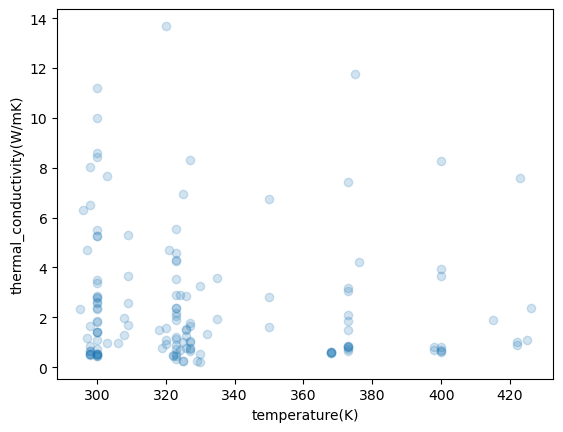

In [57]:
#temperatures after
plt.scatter(unique.loc[:,'temperature(K)'],unique.loc[:,'thermal_conductivity(W/mK)'],alpha=0.2)
plt.xlabel("temperature(K)")
plt.ylabel("thermal_conductivity(W/mK)")

In [59]:
#manually setting up the information for each; some include ML-CP some information from ML-CP results, most do not
filtered['net_MLCP']="" #net ML-CP from ML-CP, in GPa
filtered['rattlercount']="" #number and element of the most rattling-looking atom
filtered['Xs']="" #s-character of rattler site
filtered['CP']="" #CP of rattler site
filtered['mechanism']="" #suspected mechanism based on ML-CP visualization
filtered['rattler']="" #if i thought there was an (isotropic) rattler
filtered['CIF']="" #if there was an issue with the CIF

In [60]:
#Ag8SnSe6
index=filtered[filtered['Formula']=='Ag8SnSe6'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-65.78
filtered.loc[index,'rattler']=False 
filtered.loc[index,'mechanism']="maybe layers?" 
filtered.loc[index,'rattlercount']= "2 Ag"
filtered.loc[index,'Xs']= 0.65
filtered.loc[index,'CP']= -274
filtered.loc[index,'CIF']= ""

In [61]:
#SnSe
index=filtered[filtered['Formula']=='SnSe'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-27.81
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']="layers."
filtered.loc[index,'rattlercount']= "1 Se"
filtered.loc[index,'Xs']= 0.27
filtered.loc[index,'CP']= -74
filtered.loc[index,'CIF']= ""

In [62]:
#Tl2GeTe3
index=filtered[filtered['Formula']=='Tl2GeTe3'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-34.79
filtered.loc[index,'rattler']=True
filtered.loc[index,'mechanism']="rattlers. units."
filtered.loc[index,'rattlercount']= "2 Tl"
filtered.loc[index,'Xs']= 0.93
filtered.loc[index,'CP']= -75
filtered.loc[index,'CIF']= ""

In [63]:
#Cu7PS6
index=filtered[filtered['Formula']=='Cu7PS6'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=10.39
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']="disordered. maybe layers?"
filtered.loc[index,'rattlercount']= "1 S"
filtered.loc[index,'Xs']= 0.91
filtered.loc[index,'CP']= 160
filtered.loc[index,'CIF']= "disordered."

In [64]:
#Ag8GeTe6
index=filtered[filtered['Formula']=='Ag8GeTe6'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "disordered."

In [65]:
#Cu7PSe6
index=filtered[filtered['Formula']=='Cu7PSe6'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "disordered."

In [66]:
#TiS2
index=filtered[filtered['Formula']=='TiS2'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-64.72
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']="layers."
filtered.loc[index,'rattlercount']= "1 Ti"
filtered.loc[index,'Xs']= 0.89
filtered.loc[index,'CP']= 72
filtered.loc[index,'CIF']= ""

In [67]:
#CoS2
index=filtered[filtered['Formula']=='CoS2'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=30.41
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']="lack."
filtered.loc[index,'rattlercount']= "1 Co"
filtered.loc[index,'Xs']= 0.96
filtered.loc[index,'CP']= 133
filtered.loc[index,'CIF']= ""

In [68]:
#CoSi
index=filtered[filtered['Formula']=='CoSi'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-12.15
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']="lack."
filtered.loc[index,'rattlercount']= "1 Co"
filtered.loc[index,'Xs']= 0.06
filtered.loc[index,'CP']= -38
filtered.loc[index,'CIF']= ""

In [69]:
#CuFeS2
index=filtered[filtered['Formula']=='CuFeS2'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=96.17
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']="lack."
filtered.loc[index,'rattlercount']= "1 Cu 1 Fe"
filtered.loc[index,'Xs']= 0.84
filtered.loc[index,'CP']= 215
filtered.loc[index,'CIF']= ""

In [70]:
#CuFeS2
index=filtered[filtered['Formula']=='CuFeS2'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=96.17
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']="lack."
filtered.loc[index,'rattlercount']= "1 Cu 1 Fe"
filtered.loc[index,'Xs']= 0.84
filtered.loc[index,'CP']= 215
filtered.loc[index,'CIF']= ""

In [71]:
#Co9S8
index=filtered[filtered['Formula']=='Co9S8'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=44.18
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']="lack."
filtered.loc[index,'rattlercount']= "1 Co"
filtered.loc[index,'Xs']= 1.00
filtered.loc[index,'CP']= 136
filtered.loc[index,'CIF']= ""

In [72]:
#ZrNiPb
index=filtered[filtered['Formula']=='ZrNiPb'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [73]:
#VFeSb
index=filtered[filtered['Formula']=='VFeSb'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-25.60
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']=""
filtered.loc[index,'rattlercount']= "1 Sb"
filtered.loc[index,'Xs']= 0.98
filtered.loc[index,'CP']= 75
filtered.loc[index,'CIF']= ""

In [74]:
#Li2Ge11Sb2Te15
index=filtered[filtered['Formula']=='Li2Ge11Sb2Te15'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [75]:
#YbCd2Sb2
index=filtered[filtered['Formula']=='YbCd2Sb2'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-78.88
filtered.loc[index,'rattler']=True
filtered.loc[index,'mechanism']=""
filtered.loc[index,'rattlercount']= "1 Yb"
filtered.loc[index,'Xs']= 0.98
filtered.loc[index,'CP']= -475
filtered.loc[index,'CIF']= ""

In [76]:
#Ge12Sb2Te15
index=filtered[filtered['Formula']=='Ge12Sb2Te15'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [77]:
#Ag2Se
index=filtered[filtered['Formula']=='Ag2Se'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "disordered."

In [78]:
#MgAgSb
index=filtered[filtered['Formula']=='MgAgSb'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-0.93
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']=""
filtered.loc[index,'rattlercount']= "0.25 Ag"
filtered.loc[index,'Xs']= 0.84
filtered.loc[index,'CP']= -93
filtered.loc[index,'CIF']= ""

In [79]:
#Sb2Si2Te6
index=filtered[filtered['Formula']=='Sb2Si2Te6'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-145.21
filtered.loc[index,'rattler']=True
filtered.loc[index,'mechanism']=""
filtered.loc[index,'rattlercount']= "2 Sb"
filtered.loc[index,'Xs']= 0.98
filtered.loc[index,'CP']= -428
filtered.loc[index,'CIF']= ""

In [80]:
#Li2Ge3Sb2Te7
index=filtered[filtered['Formula']=='Li2Ge3Sb2Te7'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [81]:
#Tl4SnTe3
index=filtered[filtered['Formula']=='Tl4SnTe3'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-26.67
filtered.loc[index,'rattler']=True
filtered.loc[index,'mechanism']=""
filtered.loc[index,'rattlercount']= "1 Sn 1 Te"
filtered.loc[index,'Xs']= 0.98
filtered.loc[index,'CP']= -80
filtered.loc[index,'CIF']= ""

In [82]:
#Bi2Te3
index=filtered[filtered['Formula']=='Bi2Te3'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-14.73
filtered.loc[index,'rattler']=True
filtered.loc[index,'mechanism']=""
filtered.loc[index,'rattlercount']= "1 Te 1 Te"
filtered.loc[index,'Xs']= 0.96
filtered.loc[index,'CP']= -110
filtered.loc[index,'CIF']= ""

In [83]:
#LiCoO2
index=filtered[filtered['Formula']=='LiCoO2'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=61.30
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']=""
filtered.loc[index,'rattlercount']= "1 Li 1 Co (74, 182)"
filtered.loc[index,'Xs']= 0.98
filtered.loc[index,'CP']= 128
filtered.loc[index,'CIF']= ""

In [84]:
#GeTe
index=filtered[filtered['Formula']=='GeTe'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-2.31
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']=""
filtered.loc[index,'rattlercount']= "0.33 Te"
filtered.loc[index,'Xs']= 0.21
filtered.loc[index,'CP']= 10
filtered.loc[index,'CIF']= ""

In [85]:
#FeVSb
index=filtered[filtered['Formula']=='FeVSb'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [86]:
#CoGeTe
index=filtered[filtered['Formula']=='CoGeTe'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-13.69
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']=""
filtered.loc[index,'rattlercount']= "1 Te"
filtered.loc[index,'Xs']= 0.21
filtered.loc[index,'CP']= -96
filtered.loc[index,'CIF']= ""

In [87]:
#YbSi2
index=filtered[filtered['Formula']=='YbSi2'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-25.84
filtered.loc[index,'rattler']=True
filtered.loc[index,'mechanism']=""
filtered.loc[index,'rattlercount']= "1 Yb"
filtered.loc[index,'Xs']= 0.97
filtered.loc[index,'CP']= -158
filtered.loc[index,'CIF']= ""

In [88]:
#NbCoSn
index=filtered[filtered['Formula']=='NbCoSn'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [89]:
#Ag8SiSe6
index=filtered[filtered['Formula']=='Ag8SiSe6'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [90]:
#Yb9Ca4BaMgSb11
index=filtered[filtered['Formula']=='Yb9Ca4BaMgSb11'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [91]:
#Cu12Sb4S13
index=filtered[filtered['Formula']=='Cu12Sb4S13'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=41.22
filtered.loc[index,'rattler']=False
filtered.loc[index,'mechanism']=""
filtered.loc[index,'rattlercount']= "1 S"
filtered.loc[index,'Xs']= 0.97
filtered.loc[index,'CP']= 204
filtered.loc[index,'CIF']= ""

In [92]:
#As2Te2Se
index=filtered[filtered['Formula']=='As2Te2Se'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [93]:
#BaBiTe3
index=filtered[filtered['Formula']=='BaBiTe3'].index.values.astype(int)[0]
filtered.loc[index,'net_MLCP']=-21.52
filtered.loc[index,'rattler']=True
filtered.loc[index,'mechanism']=""
filtered.loc[index,'rattlercount']= "0.5 Ba 0.5 Ba 0.5 Te 0.5 Te (0.98 0.95 0.85 0.88) (-33 -40 -76 -77)"
filtered.loc[index,'Xs']= 0.96
filtered.loc[index,'CP']= -36
filtered.loc[index,'CIF']= ""

In [94]:
#LaCoO3
index=filtered[filtered['Formula']=='LaCoO3'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "element."

In [95]:
#Eu2ZnSb2
index=filtered[filtered['Formula']=='Eu2ZnSb2'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [96]:
#Cu11ZnSb4S13
index=filtered[filtered['Formula']=='Cu11ZnSb4S13'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [97]:
#CsNd2Ag3Te5
index=filtered[filtered['Formula']=='CsNd2Ag3Te5'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [98]:
#CsTb2Ag3Te5
index=filtered[filtered['Formula']=='CsTb2Ag3Te5'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [99]:
#Yb10Ca3BaMgSb11
index=filtered[filtered['Formula']=='Yb10Ca3BaMgSb11'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [100]:
#Yb7Ca6BaMgSb11
index=filtered[filtered['Formula']=='Yb7Ca6BaMgSb11'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [101]:
#Yb8Ca5BaMgSb11
index=filtered[filtered['Formula']=='Yb8Ca5BaMgSb11'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [102]:
#Ca14MgSb11
index=filtered[filtered['Formula']=='Ca14MgSb11'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [103]:
#BaErCo4O7
index=filtered[filtered['Formula']=='BaErCo4O7'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [104]:
#Ca10ZnSb9
index=filtered[filtered['Formula']=='Ca10ZnSb9'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [105]:
#Ca9Yb2Sb10
index=filtered[filtered['Formula']=='Ca9Yb2Sb10'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [106]:
#Yb11Ca2BaMgSb11
index=filtered[filtered['Formula']=='Yb11Ca2BaMgSb11'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [107]:
#Ag3RbMo9Se11
index=filtered[filtered['Formula']=='Ag3RbMo9Se11'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [108]:
#Ca10GaSb9
index=filtered[filtered['Formula']=='Ca10GaSb9'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [109]:
#Yb12CaBaMgSb11
index=filtered[filtered['Formula']=='Yb12CaBaMgSb11'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [110]:
#Ca9Yb2Sb9Ge
index=filtered[filtered['Formula']=='Ca9Yb2Sb9Ge'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [111]:
#Ca10MnSb9
index=filtered[filtered['Formula']=='Ca10MnSb9'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [112]:
#Mg2ZnSb2
index=filtered[filtered['Formula']=='Mg2ZnSb2'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [113]:
#Ca10InSb9
index=filtered[filtered['Formula']=='Ca10InSb9'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [114]:
#Yb13CaMnSb11
index=filtered[filtered['Formula']=='Yb13CaMnSb11'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [115]:
#Yb14MgSb11
index=filtered[filtered['Formula']=='Yb14MgSb11'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [116]:
#Yb10LaCdSb9
index=filtered[filtered['Formula']=='Yb10LaCdSb9'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [117]:
#AgSbTe2
index=filtered[filtered['Formula']=='AgSbTe2'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [118]:
#Ca9Yb2Sb7Ge3
index=filtered[filtered['Formula']=='Ca9Yb2Sb7Ge3'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [119]:
#Ca6Yb5Sb10
index=filtered[filtered['Formula']=='Ca6Yb5Sb10'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [120]:
#AgCuTe
index=filtered[filtered['Formula']=='AgCuTe'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [121]:
#Pb6Bi2Se9
index=filtered[filtered['Formula']=='Pb6Bi2Se9'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [122]:
#Cu26Ti2Sb4Ge2S32
index=filtered[filtered['Formula']=='Cu26Ti2Sb4Ge2S32'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [123]:
#Ba2CoRuO6
index=filtered[filtered['Formula']=='Ba2CoRuO6'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [124]:
#TmCuTe2
index=filtered[filtered['Formula']=='TmCuTe2'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [125]:
#Ca2Yb9Sb9Ge
index=filtered[filtered['Formula']=='Ca2Yb9Sb9Ge'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [126]:
#AgCuSe
index=filtered[filtered['Formula']=='AgCuSe'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [127]:
#Cu26V2Ge3Sb3S32
index=filtered[filtered['Formula']=='Cu26V2Ge3Sb3S32'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [128]:
#Ca2Yb9Sb10
index=filtered[filtered['Formula']=='Ca2Yb9Sb10'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [129]:
#CrSe3
index=filtered[filtered['Formula']=='CrSe3'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [130]:
#Ba8Cu5Si25Ge16
index=filtered[filtered['Formula']=='Ba8Cu5Si25Ge16'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [131]:
#Cd2Cu3In3Te8
index=filtered[filtered['Formula']=='Cd2Cu3In3Te8'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [132]:
#Cu26Ti2Sb3Ge3S32
index=filtered[filtered['Formula']=='Cu26Ti2Sb3Ge3S32'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [133]:
#(SnTe)8Sb2Te3
index=filtered[filtered['Formula']=='(SnTe)8Sb2Te3'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [134]:
#Ge4Sb2Te7
index=filtered[filtered['Formula']=='Ge4Sb2Te7'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [135]:
#Cu2Se
index=filtered[filtered['Formula']=='Cu2Se'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "disordered."

In [136]:
#(SnTe)10Sb2Te3	
index=filtered[filtered['Formula']=='(SnTe)10Sb2Te3'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [137]:
#Cu26V2Ge4Sb2S32	
index=filtered[filtered['Formula']=='Cu26V2Ge4Sb2S32'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [138]:
#Cu22Sn9SbS32
index=filtered[filtered['Formula']=='Cu22Sn9SbS32'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [139]:
#CoAsSb
index=filtered[filtered['Formula']=='CoAsSb'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [140]:
#Ca3Co4O9	
index=filtered[filtered['Formula']=='Ca3Co4O9'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [141]:
#Ge9Sb2Te12	
index=filtered[filtered['Formula']=='Ge9Sb2Te12'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [142]:
#(SnTe)12Sb2Te3	
index=filtered[filtered['Formula']=='(SnTe)12Sb2Te3'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [143]:
#LaCo4Sb12	
index=filtered[filtered['Formula']=='LaCo4Sb12'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [144]:
#Cu22Sn10S32	
index=filtered[filtered['Formula']=='Cu22Sn10S32'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [145]:
#Zn2Cu3In3Te8		
index=filtered[filtered['Formula']=='Zn2Cu3In3Te8'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [146]:
#(SnTe)15Sb2Te3	
index=filtered[filtered['Formula']=='(SnTe)15Sb2Te3'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [147]:
#Mg2Cu3In3Te8		
index=filtered[filtered['Formula']=='Mg2Cu3In3Te8'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "partial."

In [148]:
#Cu26V2Ge5SbS32
index=filtered[filtered['Formula']=='Cu26V2Ge5SbS32'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [149]:
#CuMo6Te8
index=filtered[filtered['Formula']=='CuMo6Te8'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [150]:
#AgMo6Te8
index=filtered[filtered['Formula']=='AgMo6Te8'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [151]:
#(SnTe)20Sb2Te3	
index=filtered[filtered['Formula']=='(SnTe)20Sb2Te3'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [152]:
#(SnTe)25Sb2Te3
index=filtered[filtered['Formula']=='(SnTe)25Sb2Te3'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [153]:
#Cu5SnSbSe7
index=filtered[filtered['Formula']=='Cu5SnSbSe7'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [154]:
#(SnTe)40Sb2Te3
index=filtered[filtered['Formula']=='(SnTe)40Sb2Te3'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "missing."

In [155]:
#TiO2
index=filtered[filtered['Formula']=='TiO2'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "ceramic."

In [156]:
#BaHoCo4O7
index=filtered[filtered['Formula']=='BaHoCo4O7'].index.values.astype(int)[0]
filtered.loc[index,'CIF']= "element."


In [157]:
findthese=filtered.sort_values(by=['CIF','rattler'])
findthese=findthese.reset_index()

In [160]:
findthese #all the 143 integer coefficient ones

,index,Formula,temperature(K),seebeck_coefficient(μV/K),electrical_conductivity(S/m),thermal_conductivity(W/mK),power_factor(W/mK2),ZT,reference,net_MLCP,rattlercount,Xs,CP,mechanism,rattler,CIF
0,4,Ag8SnSe6,330,-543.0,99.0,0.21,0.00003,0.05,https://doi.org/10.1021/acsami.1c17548,-65.78,2 Ag,0.65,-274,maybe layers?,False,
1,99,Cu12Sb4S13,322,96.0,14111.0,0.49,0.00013,0.08,https://doi.org/10.1021/acs.chemmater.6b04950,41.22,1 S,0.97,204,,False,
2,450,MgAgSb,300,172.0,49818.0,1.07,0.00148,0.42,https://doi.org/10.1021/cm5041826,-0.93,0.25 Ag,0.84,-93,,False,
3,535,SnSe,300,332.0,1174.0,1.40,0.00013,0.03,https://doi.org/10.1021/acs.chemmater.0c03657,-27.81,1 Se,0.27,-74,layers.,False,
4,728,TiS2,300,-251.0,58824.0,2.37,0.00371,0.02,10.1103/PhysRevB.64.241104,-64.72,1 Ti,0.89,72,layers.,False,
5,975,VFeSb,350,-180.0,129819.0,6.75,0.00419,0.22,https://doi.org/10.1021/acs.chemmater.0c01189,-25.6,1 Sb,0.98,75,,False,
6,990,LiCoO2,423,1052.0,0.0,7.59,0.00000,0.00,https://doi.org/10.1021/acs.inorgchem.7b00476,61.3,"1 Li 1 Co (74, 182)",0.98,128,,False,
7,995,GeTe,298,27.0,741237.0,8.04,0.00054,0.02,https://doi.org/10.1021/acs.chemmater.1c00331,-2.31,0.33 Te,0.21,10,,False,
8,1000,CoGeTe,327,-176.0,5850.0,8.30,0.00018,0.01,https://doi.org/10.1021/acs.inorgchem.1c01538,-13.69,1 Te,0.21,-96,,False,
9,1002,CuFeS2,300,-362.0,5270.0,8.43,0.00069,0.02,10.1021/acs.jpcc.6b10308,96.17,1 Cu 1 Fe,0.84,215,lack.,False,


In [164]:
cifgood=findthese[findthese['CIF']==""] 

In [165]:
formulas=np.array(cifgood['Formula'])

In [166]:
cifgood #those with CIFs that existed and worked with ML-CP

,index,Formula,temperature(K),seebeck_coefficient(μV/K),electrical_conductivity(S/m),thermal_conductivity(W/mK),power_factor(W/mK2),ZT,reference,net_MLCP,rattlercount,Xs,CP,mechanism,rattler,CIF
0,4,Ag8SnSe6,330,-543.0,99.0,0.21,0.00003,0.05,https://doi.org/10.1021/acsami.1c17548,-65.78,2 Ag,0.65,-274,maybe layers?,False,
1,99,Cu12Sb4S13,322,96.0,14111.0,0.49,0.00013,0.08,https://doi.org/10.1021/acs.chemmater.6b04950,41.22,1 S,0.97,204,,False,
2,450,MgAgSb,300,172.0,49818.0,1.07,0.00148,0.42,https://doi.org/10.1021/cm5041826,-0.93,0.25 Ag,0.84,-93,,False,
3,535,SnSe,300,332.0,1174.0,1.40,0.00013,0.03,https://doi.org/10.1021/acs.chemmater.0c03657,-27.81,1 Se,0.27,-74,layers.,False,
4,728,TiS2,300,-251.0,58824.0,2.37,0.00371,0.02,10.1103/PhysRevB.64.241104,-64.72,1 Ti,0.89,72,layers.,False,
5,975,VFeSb,350,-180.0,129819.0,6.75,0.00419,0.22,https://doi.org/10.1021/acs.chemmater.0c01189,-25.6,1 Sb,0.98,75,,False,
6,990,LiCoO2,423,1052.0,0.0,7.59,0.00000,0.00,https://doi.org/10.1021/acs.inorgchem.7b00476,61.3,"1 Li 1 Co (74, 182)",0.98,128,,False,
7,995,GeTe,298,27.0,741237.0,8.04,0.00054,0.02,https://doi.org/10.1021/acs.chemmater.1c00331,-2.31,0.33 Te,0.21,10,,False,
8,1000,CoGeTe,327,-176.0,5850.0,8.30,0.00018,0.01,https://doi.org/10.1021/acs.inorgchem.1c01538,-13.69,1 Te,0.21,-96,,False,
9,1002,CuFeS2,300,-362.0,5270.0,8.43,0.00069,0.02,10.1021/acs.jpcc.6b10308,96.17,1 Cu 1 Fe,0.84,215,lack.,False,


In [167]:
cifgood.to_csv('mlcpdatabasedata.csv')
cifgood.to_pickle('mlcpdatabasedata.pkl')

In [122]:
#brief HMS overview/standards
#weird ones:
#Cu2Se, alpha form, supposedly monoclinic per the paper but nothing there is. #do one thats there
#many different Fm-3m things, most are disorded
#TiO2, some uncertainty, can't see source paper #no, wrong class
#Ag8SnSe6, partial or not #keep
#VFeSb: occupancy question, "ideal" found a resolved one #keep
#AgBiSe2: says 2 exist at low temp, many gamma P -3 m 1 listed, R -3 m suggested to be the one in paper #do P, either?
#BaLuCo4O7, BaHoCo4O7, BaDyCo4O7: all supposed to be P31c instead of previously believed P63mc #fine
#EuCd2Sb2/EuZn2Sb2: probably fine, P -3 m 1 instead of -P m 1 #ok
#Cu2SnS3: monoclinic (good), cubic, and tetragonal seem to coexist, latter 2 are functional? #ok

In [131]:
formulas

array(['Ag8SnSe6', 'Cu12Sb4S13', 'MgAgSb', 'SnSe', 'TiS2', 'VFeSb',
       'LiCoO2', 'GeTe', 'CoGeTe', 'CuFeS2', 'Co9S8', 'CoS2', 'CoSi',
       'Tl2GeTe3', 'BaBiTe3', 'Tl4SnTe3', 'Sb2Si2Te6', 'Bi2Te3',
       'YbCd2Sb2', 'YbSi2', 'Rb2Bi8Se13', 'AgBiSe2', 'BaTmCo4O7',
       'BaLuCo4O7', 'BaDyCo4O7', 'CsPr2Ag3Te5', 'CsSm2Ag3Te5', 'TlCr5Se8',
       'Ca14MgBi11', 'BiCuSeO', 'Ca11Sb10', 'As2Te3', 'Bi2Si2Te6',
       'Ca5In2Sb6', 'Cr2Ge2Te6', 'Ca3AlSb3', 'Yb14MnSb11', 'Ca5Ga2Sb6',
       'Tl4PbTe3', 'Sr14MgBi11', 'Mg3Sb2', 'EuCd2Sb2', 'SnS',
       'Eu14MgBi11', 'Yb14MgBi11', 'Cu3SbS4', 'BaZn2As2', 'PbTe',
       'Cu2SnSe3', 'BaGd2NiO5', 'Cu2SnS3', 'Cu3ErTe3', 'EuZn2Sb2',
       'Cu2CdSnSe4', 'GeSe', 'Nd3Te4', 'Cu3SbSe4', 'ZrNiSn', 'Cu2ZnSnSe4',
       'CaTiO3', 'TiNiSn', 'Cu5Sn2Se7', 'Cu26V2Ge6S32', 'Cu5Sn2S7',
       'SnTe', 'CuGaTe2', 'Ca3Co2O6'], dtype=object)

In [132]:
len(formulas)

67